In [148]:
pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [149]:
import pandas as pd

# Load dataset
df = pd.read_csv("C:\\Users\\DINESH\\OneDrive\\Desktop\\Realistic_Telco_Churn.csv")

# First look
print(df.head())

   gender  SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Contract  \
0  Female              1      52           45.47       2364.29  Two year   
1    Male              1      15          104.09       1561.31  One year   
2  Female              1      61           23.84       1454.40  Two year   
3    Male              0      21          110.18       2313.70  One year   
4  Female              1      24           66.15       1587.55  Two year   

  InternetService              PaymentMethod Churn  
0              No    Credit card (automatic)    No  
1             DSL           Electronic check    No  
2             DSL               Mailed check    No  
3     Fiber optic           Electronic check   Yes  
4     Fiber optic  Bank transfer (automatic)   Yes  


In [150]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           2000 non-null   object 
 1   SeniorCitizen    2000 non-null   int64  
 2   tenure           2000 non-null   int64  
 3   MonthlyCharges   2000 non-null   float64
 4   TotalCharges     2000 non-null   float64
 5   Contract         2000 non-null   object 
 6   InternetService  2000 non-null   object 
 7   PaymentMethod    2000 non-null   object 
 8   Churn            2000 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 140.8+ KB
None
       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    2000.000000  2000.000000     2000.000000   2000.000000
mean        0.480500    35.191500       69.849745   2458.778995
std         0.499745    20.516366       28.805891   1874.122686
min         0.000000     1.000000       20.000000     25.780000

In [151]:
df.dropna(inplace=True)

In [152]:
#df.drop('customerID', axis=1, inplace=True)

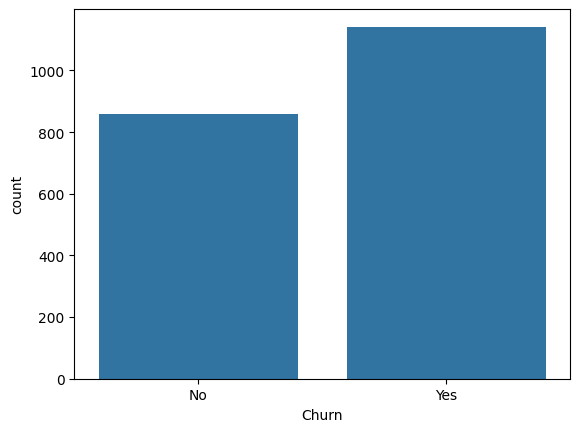

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)
plt.show()

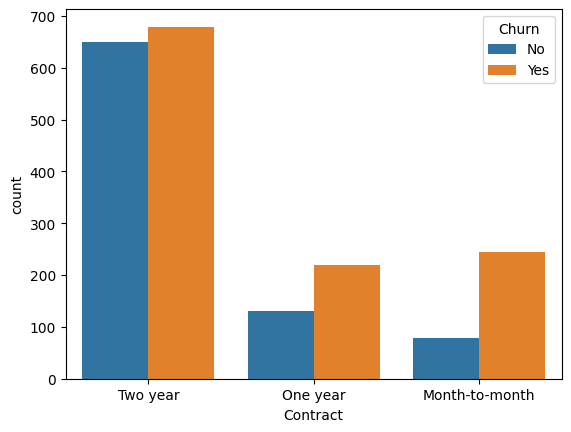

In [154]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

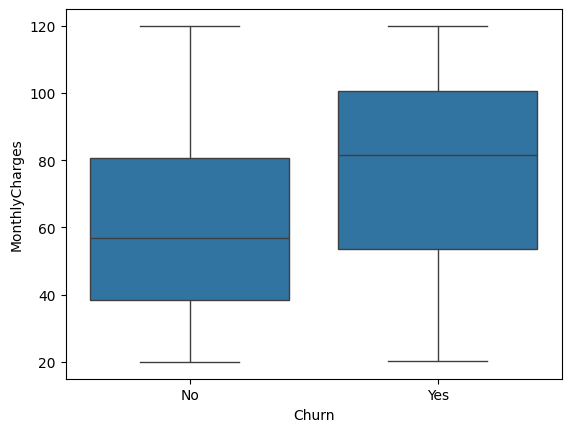

In [155]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

In [156]:
df = pd.get_dummies(df, drop_first=True)

In [157]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn_Yes', axis=1)
y = df['Churn_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

Model Building

In [184]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred))

Logistic Regression Accuracy: 0.66


c:\Users\DINESH\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [185]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.66
[[ 88  87]
 [ 49 176]]
              precision    recall  f1-score   support

           0       0.64      0.50      0.56       175
           1       0.67      0.78      0.72       225

    accuracy                           0.66       400
   macro avg       0.66      0.64      0.64       400
weighted avg       0.66      0.66      0.65       400



Customers with month-to-month contracts are more likely to churn
Higher monthly charges → higher churn
Long-term customers churn less

In [167]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

print("RF Accuracy:", accuracy_score(y_test, rf.predict(X_test)))

RF Accuracy: 0.615


In [172]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

print("DT Accuracy:", accuracy_score(y_test, dt.predict(X_test)))

DT Accuracy: 0.6025


In [177]:
#call KNN classifier
from sklearn.neighbors import KNeighborsClassifier

#initiating the classifier
knn = KNeighborsClassifier()

#Passing data to the classifier
knn.fit(X_train, y_train)
print("KNN Accuracy:", accuracy_score(y_test, knn.predict(X_test)))


KNN Accuracy: 0.63


In [179]:
#call navie bayes classifier
from sklearn.naive_bayes import BernoulliNB

#initiating the classifier
nb = BernoulliNB()

#Passing data to the classifier
nb.fit(X_train, y_train)

#Accuracy
print("NB Accuracy:", accuracy_score(y_test, nb.predict(X_test)))

NB Accuracy: 0.575


In [182]:
# SVM
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train, y_train)
print("SVM Accuracy:", accuracy_score(y_test, svm.predict(X_test)))

SVM Accuracy: 0.5625


In [187]:
import pickle

pickle.dump(lr, open("model.pkl", "wb"))
pickle.dump(X.columns, open("columns.pkl", "wb"))

NameError: name 'lr' is not defined